# ResNet-50 (Full layer4 Unfreeze — WD 1e-3 + L1 + L2 Penalty)

## Changes from Iteration 04

| | 04. layer4 + WD=1e-3 | 05. layer4 + WD + L1 + L2 |
|---|---|---|
| Unfrozen | All of `layer4` | All of `layer4` |
| Weight decay (AdamW) | 1e-3 | 1e-3 |
| L1 lambda | — | **1e-3** |
| L2 lambda | — | **1e-3** |
| LR — layer4 | 1e-4 | 1e-4 |
| LR — FC head | 1e-3 | 1e-3 |
| Dropout | 0.5 | 0.5 |
| Epochs | 30 | 30 |

## Rationale

Iterations 02–04 show that weight decay alone (even at 1e-3) cannot close the train/val gap when fine-tuning all of `layer4`. The gap stays at ~0.23 regardless.

This iteration stacks explicit **L1 and L2 penalty terms** on top of AdamW weight decay:
- **L1** adds sparsity pressure — drives less-useful weights toward zero, which AdamW's L2-style decay cannot do.
- **L2** adds further weight shrinkage on top of AdamW's built-in decay.

### Lambda scaling
The penalty functions sum over all trainable parameters (`requires_grad=True`). With ~15M trainable params here vs ~2M in the EfficientNet penalty experiments, using the same lambda (1e-3) would make the penalty term ~7x larger relative to the BCE loss. Lambdas are scaled down to **1e-5** to keep the penalty contribution proportionate — roughly equivalent effective regularisation strength to the 1e-3 used in the best EfficientNet runs.

In [10]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [11]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [12]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [13]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


In [14]:
model = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.5).to(device)

for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-3)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 1e-3

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA}')

Trainable params: 14,966,785 / 23,510,081
L1 lambda: 0.001 | L2 lambda: 0.001


In [15]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_layer4_l1_l2_best.pth')
        print(f'  -> Saved best model (val F2: {best_val_f2:.4f})')

Epoch [1/30] | Train Loss: 0.9767, Bal Acc: 0.7050, Recall: 0.7286, F2: 0.4982 | Val Loss: 0.8596, Bal Acc: 0.7551, Recall: 0.9068, F2: 0.5731
  -> Saved best model (val F2: 0.5731)


Epoch [2/30] | Train Loss: 0.8475, Bal Acc: 0.7669, Recall: 0.8221, F2: 0.5740 | Val Loss: 0.8325, Bal Acc: 0.7614, Recall: 0.8814, F2: 0.5800
  -> Saved best model (val F2: 0.5800)


Epoch [3/30] | Train Loss: 0.8435, Bal Acc: 0.7728, Recall: 0.8164, F2: 0.5821 | Val Loss: 0.8668, Bal Acc: 0.7776, Recall: 0.7627, F2: 0.6020
  -> Saved best model (val F2: 0.6020)


Epoch [4/30] | Train Loss: 0.8293, Bal Acc: 0.7741, Recall: 0.8005, F2: 0.5845 | Val Loss: 0.8108, Bal Acc: 0.7754, Recall: 0.8305, F2: 0.5976


Epoch [5/30] | Train Loss: 0.8404, Bal Acc: 0.7741, Recall: 0.8096, F2: 0.5841 | Val Loss: 0.9139, Bal Acc: 0.7518, Recall: 0.6568, F2: 0.5645


...

Epoch [26/30] | Train Loss: 0.6451, Bal Acc: 0.8312, Recall: 0.8666, F2: 0.6643 | Val Loss: 0.7297, Bal Acc: 0.8089, Recall: 0.8432, F2: 0.6436


Epoch [27/30] | Train Loss: 0.6188, Bal Acc: 0.8375, Recall: 0.8689, F2: 0.6745 | Val Loss: 0.7524, Bal Acc: 0.7972, Recall: 0.8305, F2: 0.6274


Epoch [28/30] | Train Loss: 0.6171, Bal Acc: 0.8410, Recall: 0.8700, F2: 0.6803 | Val Loss: 0.7371, Bal Acc: 0.7981, Recall: 0.8390, F2: 0.6282


Epoch [29/30] | Train Loss: 0.6379, Bal Acc: 0.8410, Recall: 0.8757, F2: 0.6792 | Val Loss: 0.7308, Bal Acc: 0.8076, Recall: 0.8686, F2: 0.6398


Epoch [30/30] | Train Loss: 0.5988, Bal Acc: 0.8504, Recall: 0.8883, F2: 0.6929 | Val Loss: 0.7386, Bal Acc: 0.8016, Recall: 0.8263, F2: 0.6339


## Training Curves

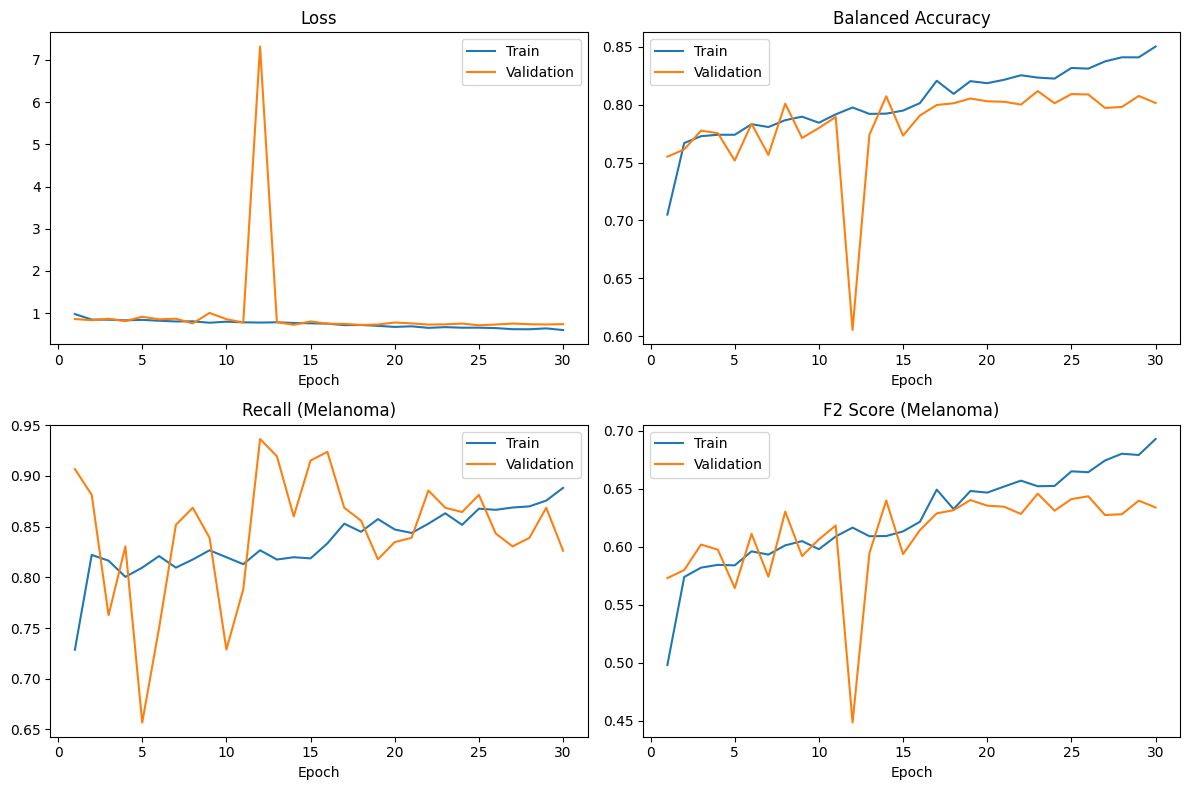

In [16]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [17]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_layer4_l1_l2_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.64 | Val F2: 0.6595


## Test Set Evaluation

Threshold:          0.64
AUC-ROC:            0.8841
Balanced Accuracy:  0.7911
F2 Score:           0.6184

              precision    recall  f1-score   support

Non-Melanoma     0.9629    0.8336    0.8936      1340
    Melanoma     0.3647    0.7485    0.4904       171

    accuracy                         0.8240      1511
   macro avg     0.6638    0.7911    0.6920      1511
weighted avg     0.8952    0.8240    0.8480      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


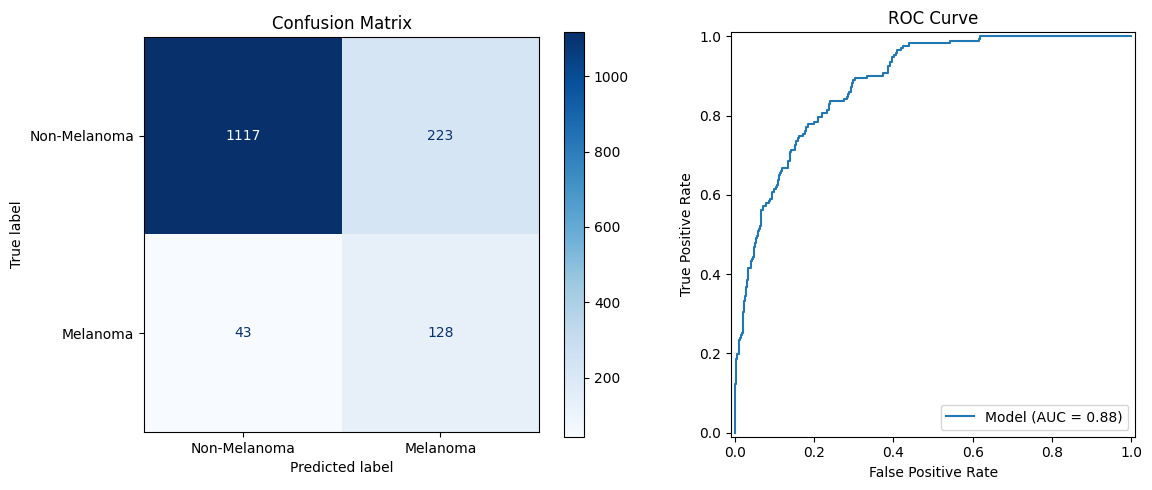

In [18]:
evaluate_model(model, test_loader, device, threshold=best_threshold)